# TP3 — Clasificación, Clustering y Ensamble
### Inteligencia Artificial y Aprendizaje Automático I · 2026
### Dataset: transacciones inmobiliarias — Prefectura de Tokio (MLIT)

Tercera etapa del proyecto integrador. Partimos del dataset limpio del TP1
(`tokyo_tp1_procesado.csv`, toda la Prefectura de Tokio) y retomamos la pregunta de clasificación:

> **¿Podemos predecir la estructura del edificio (W / S / RC / SRC) a partir de las características del
> lote, su ubicación y su entorno urbano?**

Usamos como target `estructura_principal`, la versión **normalizada** que derivó el TP1: la columna
original `Building : Structure` es multi-etiqueta (`"RC, W"`) y tiene 26 categorías, así que se redujo
al sistema constructivo principal agrupando las clases raras (`LS`, `B`) en `"Otros"`.

**Organización del trabajo**, siguiendo la estructura del enunciado:

- **Sección B (núcleo):** tres clasificadores supervisados de familias distintas —Regresión Logística,
  Árbol de Decisión y Naive Bayes— con marco experimental controlado (hold-out 80/20 estratificado +
  StratifiedKFold) y métricas adecuadas al **desbalance severo** (65,6:1).
- **Sección D.1 (plus):** clustering no supervisado con determinación objetiva del número de grupos y
  contraste contra las clases reales.
- **Sección D.2 (plus):** dos métodos de ensamble (*bagging* y *boosting*) comparados contra los
  clasificadores individuales bajo idénticas condiciones.

## 0. Setup

In [8]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score,
                             classification_report, confusion_matrix, cohen_kappa_score,
                             roc_auc_score, adjusted_rand_score, silhouette_score,
                             davies_bouldin_score, precision_recall_curve, average_precision_score)

try:
    from xgboost import XGBClassifier
    HAY_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAY_XGB = False
    print("XGBoost no disponible: se usará GradientBoostingClassifier como tercer modelo.")

# --- Detección de GPU (NVIDIA) para XGBoost -------------------------------------------------
# XGBoost puede entrenar en GPU con device="cuda". Random Forest y Logística de scikit-learn
# son CPU-only, por eso se controlan vía hiperparámetros.
USAR_GPU = False
if HAY_XGB:
    try:
        import subprocess
        subprocess.run(["nvidia-smi"], capture_output=True, check=True, timeout=10)
        USAR_GPU = True
        print("GPU NVIDIA detectada: XGBoost entrenará en GPU (device='cuda').")
    except Exception:
        print("Sin GPU NVIDIA disponible: XGBoost entrenará en CPU.")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "outputs/processed/tokyo_tp1_procesado.csv"   # salida del TP1
MODEL_DIR = "outputs/models"
os.makedirs(MODEL_DIR, exist_ok=True)

GPU NVIDIA detectada: XGBoost entrenará en GPU (device='cuda').


## A. Marco experimental

### A.1 Problema
Clasificación **multiclase** de `estructura_principal`: **W** (madera), **S** (acero), **RC** (hormigón
armado), **SRC** (acero-hormigón) y **Otros** (clases marginales `LS`/`B`). Solo tiene sentido en
operaciones **con edificio**: las filas *Land Only* no tienen estructura y se excluyen.

### A.2 Desbalance — severo
El EDA del TP1 mostró que **`W` (madera) es abrumadoramente mayoritaria** (~180k casos) frente a `S` y
`RC` (~20k cada una), con `SRC` y `Otros` casi testimoniales. **Decisiones:**
- `stratify` en el split y `StratifiedKFold` en la CV para preservar la proporción de clases.
- **`class_weight="balanced"`** en los modelos que lo soportan (penaliza más el error en las clases raras).
  SMOTE queda como alternativa opcional (sección 7.1), para no depender de `imbalanced-learn`.
- Métrica prioritaria: **F1 macro**. Con este desbalance, un modelo que prediga siempre `W` alcanzaría
  una accuracy altísima siendo inútil: la accuracy es directamente engañosa acá.

### A.3 Features
Se reutilizan las mismas del TP1/TP2 (superficie, frente, `distancia_estacion_min`, antigüedad, ratios
urbanísticos, zona, forma, orientación/tipo de calle, `ward`, district/estación agrupados).
**Exclusiones:** `precio_suelo_m2` (solo Land Only) y la columna cruda `Building : Structure` (de la que
deriva el target). `Total transaction value` y `precio_por_m2` **sí pueden usarse** como predictores acá,
porque el target no es el precio.

### A.4 Modelos implementados y su encuadre

El enunciado distingue dos bloques, y este trabajo los mantiene separados para que la comparación entre
ellos resulte informativa.

**Sección B — Clasificadores supervisados (núcleo obligatorio).** Tres algoritmos de la lista sugerida,
elegidos por **diversidad de sesgo inductivo**: uno lineal, uno basado en reglas y uno probabilístico.

| Modelo | Familia | Por qué se eligió |
|---|---|---|
| **Regresión Logística** (multinomial) | Lineal | Baseline recomendado por el enunciado. Interpretable vía coeficientes; fija el piso de rendimiento. |
| **Árbol de Decisión** | Reglas / particiones | Captura umbrales e interacciones (*"si la superficie construida supera X y la antigüedad es menor a Y"*), imposibles para un modelo lineal. Sigue siendo legible. |
| **Naive Bayes Gaussiano** | Probabilístico generativo | Asume independencia condicional entre variables —supuesto falso acá, ya que las superficies están correlacionadas—. Su desempeño mide indirectamente **cuánto pesan las interacciones** que los otros modelos sí aprovechan. |

Comparar familias distintas dice más sobre la naturaleza del problema que comparar tres variantes del
mismo enfoque.

**Sección D.2 — Métodos de ensamble (actividad complementaria).** Dos ensambles, evaluados con
idénticas métricas para que la comparación contra la sección B sea directa.

| Modelo | Tipo | Qué aporta la comparación |
|---|---|---|
| **Random Forest** | *Bagging* | Comparte modelo base con el Árbol de Decisión: la diferencia entre ambos **aísla el efecto del bagging**, sin confundirlo con un cambio de algoritmo. |
| **XGBoost** | *Boosting* | Árboles secuenciales que corrigen los errores previos; contrasta la estrategia secuencial contra la paralela del *bagging*. |

**Referencia trivial.** Un `DummyClassifier` que predice siempre la clase mayoritaria. Con un desbalance
de 65,6:1 alcanza ~80,8% de exactitud sin detectar ninguna otra estructura: es la demostración numérica
de por qué esa métrica engaña en este problema.

## 1. Carga del dataset procesado del TP1

In [9]:
df = pd.read_csv(DATA_PATH)
print("Shape del dataset completo:", df.shape)
df.head(3)

Shape del dataset completo: (343995, 42)


,ward,District,district_agrupado,Nearest station : Name,estacion_agrupada,Type,Area,City planning,Land : Shape,Frontage road : Direction,Frontage road : Type,anio_operacion,trimestre_operacion,anio_construccion,antiguedad,antes_de_guerra,antiguedad_inconsistente,area_terreno_m2,area_terreno_capada,area_construida_m2,...,ratio_construido_sospechoso,Frontage,Frontage road : Width,Building coverage ratio,Floor area ratio,distancia_estacion_min,distancia_estacion_nula,uso_house,uso_office,uso_shop,uso_warehouse,uso_parking_lot,uso_housing_complex,sin_edificio,tiene_nota_transaccion,precio_suelo_m2,precio_por_m2,Total transaction value,Building : Structure,estructura_principal
0,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Rectangular Shaped,Northeast,Tokyo Metropolitan Road,2025,2,1954.0,71.0,0,0,50,False,75.0,...,0,3.5,27.0,80.0,700.0,0.0,0,1,0,1,0,0,0,0,0,NaN,6.800000e+06,340000000,W,W
1,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Irregular Shaped,Northwest,Ward Road,2024,3,2024.0,0.0,0,0,55,False,400.0,...,0,10.0,8.0,80.0,700.0,4.0,0,0,1,1,0,0,0,0,0,NaN,1.509091e+07,830000000,S,S
2,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Rectangular Shaped,South,Ward Road,2023,4,1970.0,53.0,0,0,95,False,320.0,...,0,7.5,10.6,80.0,500.0,1.0,0,1,1,0,1,0,0,0,0,NaN,1.894737e+06,180000000,RC,RC


## 2. Filtrado a operaciones con edificio y definición del target
La estructura solo existe cuando hay construcción. Nos quedamos con las filas que tienen
`estructura_principal` no nula (equivalente a `Type == Land and Building`).

In [10]:
TARGET = "estructura_principal"   # target normalizado por el TP1 (la columna cruda es multi-etiqueta)

# Solo filas con estructura reportada (las Land Only no tienen edificio).
df_clf = df[df[TARGET].notna()].copy().reset_index(drop=True)
print("Filas con edificio (usables para clasificar):", df_clf.shape[0])

# Distribución de clases: clave para dimensionar el desbalance.
dist = df_clf[TARGET].value_counts()
print("\nDistribución de clases:")
print(dist)
print("\nProporción (%):")
print((df_clf[TARGET].value_counts(normalize=True) * 100).round(2))

# Ratio de desbalance: cuántas veces la clase mayoritaria supera a la minoritaria.
print(f"\nRatio mayoritaria/minoritaria: {dist.max() / dist.min():.1f}x")

Filas con edificio (usables para clasificar): 224622

Distribución de clases:
estructura_principal
W        181477
S         16845
RC        16736
Otros      6797
SRC        2767
Name: count, dtype: int64

Proporción (%):
estructura_principal
W        80.79
S         7.50
RC        7.45
Otros     3.03
SRC       1.23
Name: proportion, dtype: float64

Ratio mayoritaria/minoritaria: 65.6x


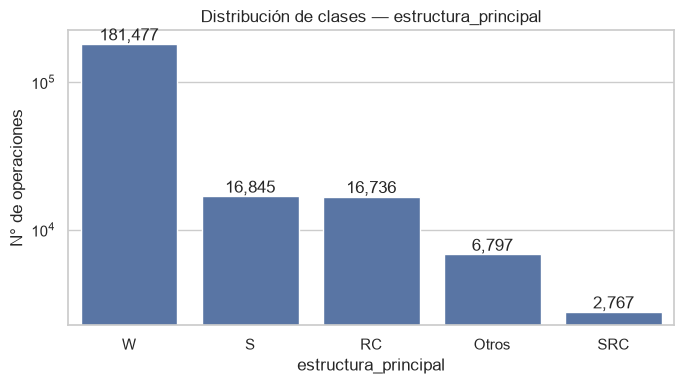

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=dist.index, y=dist.values, ax=ax, color="#4C72B0")
ax.set_title("Distribución de clases — estructura_principal")
ax.set_ylabel("N° de operaciones")
ax.set_yscale("log")   # escala log: el desbalance es tan fuerte que en lineal las clases raras no se ven
for i, v in enumerate(dist.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Definición de `X`, `y` y grupos de columnas
Excluimos `precio_suelo_m2` (solo aplica a Land Only, todo nulo acá) y las columnas geográficas crudas
de alta cardinalidad (se usan sus versiones agrupadas). El **precio de la operación sí se incluye** como
predictor de la estructura.

In [12]:
# Excluidas: el target, la columna cruda de la que deriva, y las que no aplican a este subconjunto.
#
# NOTA sobre 'sin_edificio' y 'Type': al filtrar a operaciones CON edificio, ambas quedan
# constantes (sin_edificio == 0 en las 224.622 filas). Una variable sin varianza no aporta
# información y sólo agrega ruido dimensional, así que se descartan explícitamente.
EXCLUIDAS = [TARGET, "Building : Structure", "precio_suelo_m2",
             "District", "Nearest station : Name",
             "sin_edificio", "Type"]

# NOTA DE COMPATIBILIDAD: en pandas >= 3.0, .values sobre una columna de texto devuelve un
# ArrowStringArray, que scikit-learn no acepta en `stratify` (TypeError). Se convierte
# explícitamente a un ndarray de objetos para que el split estratificado funcione.
y = np.asarray(df_clf[TARGET].values, dtype=object)
X = df_clf.drop(columns=[c for c in EXCLUIDAS if c in df_clf.columns]).copy()

# Flags booleanos a int por prolijidad.
for c in X.select_dtypes(include="bool").columns:
    X[c] = X[c].astype(int)

# Control: ninguna columna debe haber quedado constante tras el filtrado.
constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
if constantes:
    print("Se descartan columnas constantes detectadas:", constantes)
    X = X.drop(columns=constantes)

# Grupos de columnas. 'ward' entra como categórica (One-Hot dentro del pipeline) si existe.
cols_categoricas = [c for c in ["ward", "district_agrupado", "estacion_agrupada", "Area",
                                "City planning", "Land : Shape", "Frontage road : Direction",
                                "Frontage road : Type"] if c in X.columns]
cols_numericas = [c for c in X.columns if c not in cols_categoricas]

print(f"Total features: {X.shape[1]}  |  numéricas: {len(cols_numericas)}  |  categóricas: {len(cols_categoricas)}")
print("\nClases:", sorted(pd.unique(y)))

Total features: 35  |  numéricas: 27  |  categóricas: 8

Clases: ['Otros', 'RC', 'S', 'SRC', 'W']


## 4. Partición train/test estratificada
Hold-out 80/20 con `stratify=y` para que cada clase mantenga su proporción en train y test — crítico con
`W` minoritaria.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nProporción de clases en train:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

Train: (179697, 35)  Test: (44925, 35)

Proporción de clases en train:
W        0.808
S        0.075
RC       0.075
Otros    0.030
SRC      0.012
Name: proportion, dtype: float64


## 5. Preprocesamiento (ColumnTransformer)
- **Numéricas:** imputación por mediana + `StandardScaler` (necesario para la Logística; indiferente
  para los árboles, se deja en el pipeline común).
- **Categóricas:** imputación por moda + `OneHotEncoder` (viable porque el TP1 ya agrupó las raras).

In [14]:
preproc_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preproc_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocesador = ColumnTransformer([
    ("num", preproc_numerico, cols_numericas),
    ("cat", preproc_categorico, cols_categoricas),
])

## 6. Clasificadores supervisados (sección B del enunciado)

Se implementan los **tres clasificadores individuales** justificados en A.4. Los métodos de ensamble se
definen aparte, en la sección 11.4, para que el contraste entre ambos bloques quede explícito.

**Hiperparámetros y su justificación:**

- **Regresión Logística** — `max_iter=500`: el solver no converge con este volumen en las iteraciones
  por defecto. `class_weight="balanced"` pondera cada clase por el inverso de su frecuencia,
  compensando el desbalance sin recurrir a resampleo sintético.
- **Árbol de Decisión** — `max_depth=12`, `min_samples_leaf=20`: un árbol sin restricciones crece hasta
  hojas puras y memoriza el entrenamiento. Acotarlo preserva la capacidad de generalizar y mantiene el
  modelo interpretable. También con `class_weight="balanced"`.
- **Naive Bayes Gaussiano** — no admite `class_weight`. Se conservan los priors empíricos estimados de
  los datos: alterarlos distorsionaría su naturaleza generativa, y su desventaja frente al desbalance es
  precisamente parte de lo que el experimento busca medir.

In [15]:
# ---------------------------------------------------------------------------------------------
# SECCIÓN B — Tres clasificadores supervisados de familias distintas.
# ---------------------------------------------------------------------------------------------
modelos = {
    # Lineal: baseline recomendado por el enunciado.
    "Regresión Logística": LogisticRegression(
        max_iter=500, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),

    # Basado en reglas: captura interacciones y umbrales. Acotado para que no memorice el train.
    "Árbol de Decisión": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),

    # Probabilístico generativo: asume independencia condicional entre variables. Ese supuesto es
    # falso acá (las superficies están correlacionadas), y justamente por eso su desempeño mide
    # cuánto aportan las interacciones que los otros modelos sí explotan.
    "Naive Bayes": GaussianNB(),
}
print("Clasificadores de la sección B:", list(modelos.keys()))

# ---------------------------------------------------------------------------------------------
# REFERENCIA TRIVIAL — predice siempre la clase mayoritaria.
# No es un modelo a comparar: es el piso contra el que se verifica si un clasificador aprendió algo.
# ---------------------------------------------------------------------------------------------
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
acc_dummy = accuracy_score(y_test, pred_dummy)
f1_dummy = f1_score(y_test, pred_dummy, average="macro", zero_division=0)
print(f"\n[Referencia trivial] Accuracy = {acc_dummy:.3f}  |  F1 macro = {f1_dummy:.3f}")
print("La brecha entre ambas métricas es la razón por la que se prioriza F1 macro.")

Clasificadores de la sección B: ['Regresión Logística', 'Árbol de Decisión', 'Naive Bayes']

[Referencia trivial] Accuracy = 0.808  |  F1 macro = 0.179
La brecha entre ambas métricas es la razón por la que se prioriza F1 macro.


Las etiquetas del target son texto (`W`, `RC`, `S`, `SRC`, `Otros`). La Regresión Logística, el Árbol y
Naive Bayes trabajan directamente con ellas, pero **XGBoost exige enteros `0..n-1`**. Se define acá un
mapeo consistente clase↔entero que se aplicará únicamente donde haga falta (sección 11.4); todas las
predicciones se devuelven a etiquetas de texto para que las comparaciones sean homogéneas.

In [16]:
clases = sorted(pd.unique(y))
clase_a_int = {c: i for i, c in enumerate(clases)}
int_a_clase = {i: c for c, i in clase_a_int.items()}

y_train_int = np.array([clase_a_int[v] for v in y_train])
y_test_int = np.array([clase_a_int[v] for v in y_test])
print("Mapeo de clases:", clase_a_int)

Mapeo de clases: {'Otros': 0, 'RC': 1, 'S': 2, 'SRC': 3, 'W': 4}


## 7. Entrenamiento, validación cruzada y evaluación

Se define una función `entrenar_y_evaluar()` que encapsula el procedimiento completo: `Pipeline`
(preprocesamiento + modelo) → validación cruzada estratificada de 5 particiones sobre *train* →
ajuste final → métricas en *train* y *test*.

Usar la **misma función** para los clasificadores de la sección B y para los ensambles de la sección
D.2 garantiza que la comparación entre ambos bloques sea estrictamente equivalente: idéntico
preprocesamiento, idéntica validación e idénticas métricas. Cualquier diferencia observada será
atribuible al algoritmo, no al procedimiento.

In [18]:
from sklearn.preprocessing import FunctionTransformer

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def metricas_clf(y_true, y_pred):
    """Accuracy + precision/recall/F1 (macro y ponderado) + Kappa de Cohen."""
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    return {"Accuracy": acc, "Precision_macro": p_macro, "Recall_macro": r_macro,
            "F1_macro": f1_macro, "F1_weighted": f1_weighted, "Kappa": kappa}


# Registros compartidos entre la sección B y la sección D.2.
resultados = []
pipelines_entrenados = {}
predicciones_test = {}
proba_test = {}


def entrenar_y_evaluar(nombre, modelo, bloque):

    if nombre == "Naive Bayes":
        pipe = Pipeline([
            ("prep", preprocesador),
            ("dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
            ("model", modelo)
        ])
    else:
        pipe = Pipeline([
            ("prep", preprocesador),
            ("model", modelo)
        ])

    usa_int = nombre in ("XGBoost", "GradientBoosting")
    ytr = y_train_int if usa_int else y_train

    cv_f1 = cross_val_score(pipe, X_train, ytr, cv=skf, scoring="f1_macro", n_jobs=1)

    pipe.fit(X_train, ytr)
    pipelines_entrenados[nombre] = pipe

    # Predicciones: se llevan siempre a etiquetas de texto para comparar de forma homogénea.
    pred_train_raw = pipe.predict(X_train)
    pred_test_raw = pipe.predict(X_test)
    pred_train = np.array([int_a_clase[v] for v in pred_train_raw]) if usa_int else pred_train_raw
    pred_test = np.array([int_a_clase[v] for v in pred_test_raw]) if usa_int else pred_test_raw
    predicciones_test[nombre] = pred_test
    proba_test[nombre] = pipe.predict_proba(X_test)

    m_train = metricas_clf(y_train, pred_train)
    m_test = metricas_clf(y_test, pred_test)

    resultados.append({
        "Modelo": nombre, "Bloque": bloque,
        "CV_F1macro": cv_f1.mean(), "CV_F1macro_std": cv_f1.std(),
        "Acc_train": m_train["Accuracy"], "Acc_test": m_test["Accuracy"],
        "F1macro_train": m_train["F1_macro"], "F1macro_test": m_test["F1_macro"],
        "F1weighted_test": m_test["F1_weighted"], "Kappa_test": m_test["Kappa"],
    })
    # La brecha train-test es el diagnóstico de sobreajuste que pide el enunciado.
    brecha = m_train["F1_macro"] - m_test["F1_macro"]
    print(f"{nombre:22s}  CV F1macro={cv_f1.mean():.3f}±{cv_f1.std():.3f}  "
          f"F1macro(test)={m_test['F1_macro']:.3f}  Acc(test)={m_test['Accuracy']:.3f}  "
          f"brecha train-test={brecha:+.3f}")


print("=== SECCIÓN B — Clasificadores individuales ===")
for nombre, modelo in modelos.items():
    entrenar_y_evaluar(nombre, modelo, "B - Individual")

df_resultados = pd.DataFrame(resultados)

=== SECCIÓN B — Clasificadores individuales ===
Regresión Logística     CV F1macro=0.492±0.002  F1macro(test)=0.492  Acc(test)=0.725  brecha train-test=+0.011
Árbol de Decisión       CV F1macro=0.474±0.008  F1macro(test)=0.479  Acc(test)=0.703  brecha train-test=+0.048
Naive Bayes             CV F1macro=0.111±0.005  F1macro(test)=0.121  Acc(test)=0.175  brecha train-test=+0.004


### 7.1 Alternativa opcional — SMOTE
Como alternativa a `class_weight`, se puede **sobremuestrear** la clase minoritaria con SMOTE. Requiere
`imbalanced-learn` (`pip install imbalanced-learn`). Se deja como celda opcional; la estrategia principal
del TP es `class_weight`.

In [19]:
# --- OPCIONAL: descomentar si se instala imbalanced-learn ---
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.over_sampling import SMOTE
#
# pipe_smote = ImbPipeline([
#     ("prep", preprocesador),
#     ("smote", SMOTE(random_state=RANDOM_STATE)),
#     ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
# ])
# pipe_smote.fit(X_train, y_train)
# pred_smote = pipe_smote.predict(X_test)
# print("F1 macro (RF + SMOTE):", f1_score(y_test, pred_smote, average="macro"))
print("Celda opcional: SMOTE no ejecutado (estrategia principal = class_weight).")

Celda opcional: SMOTE no ejecutado (estrategia principal = class_weight).


## 8. Tabla comparativa — clasificadores de la sección B

Métricas en **train** y **test** para los tres clasificadores individuales. La columna guía es
**F1 macro** (por el desbalance); la exactitud se muestra pero con la advertencia de que engaña cuando
una clase domina.

La comparación **train vs. test** permite diagnosticar sobreajuste: una brecha amplia indica que el
modelo memorizó el conjunto de entrenamiento. Los ensambles se incorporan a esta tabla en la sección
11.4, una vez entrenados.

In [20]:
tabla_fmt = df_resultados.copy()
for c in tabla_fmt.columns:
    if c != "Modelo":
        tabla_fmt[c] = tabla_fmt[c].round(3)
tabla_fmt.set_index("Modelo")

,Bloque,CV_F1macro,CV_F1macro_std,Acc_train,Acc_test,F1macro_train,F1macro_test,F1weighted_test,Kappa_test
Modelo,,,,,,,,,
Regresión Logística,B - Individual,0.492,0.002,0.730,0.725,0.503,0.492,0.778,0.408
Árbol de Decisión,B - Individual,0.474,0.008,0.722,0.703,0.527,0.479,0.762,0.395
Naive Bayes,B - Individual,0.111,0.005,0.180,0.175,0.125,0.121,0.258,0.038


## 9. Visualizaciones comparativas

### 9.1 F1 macro por modelo (barras)

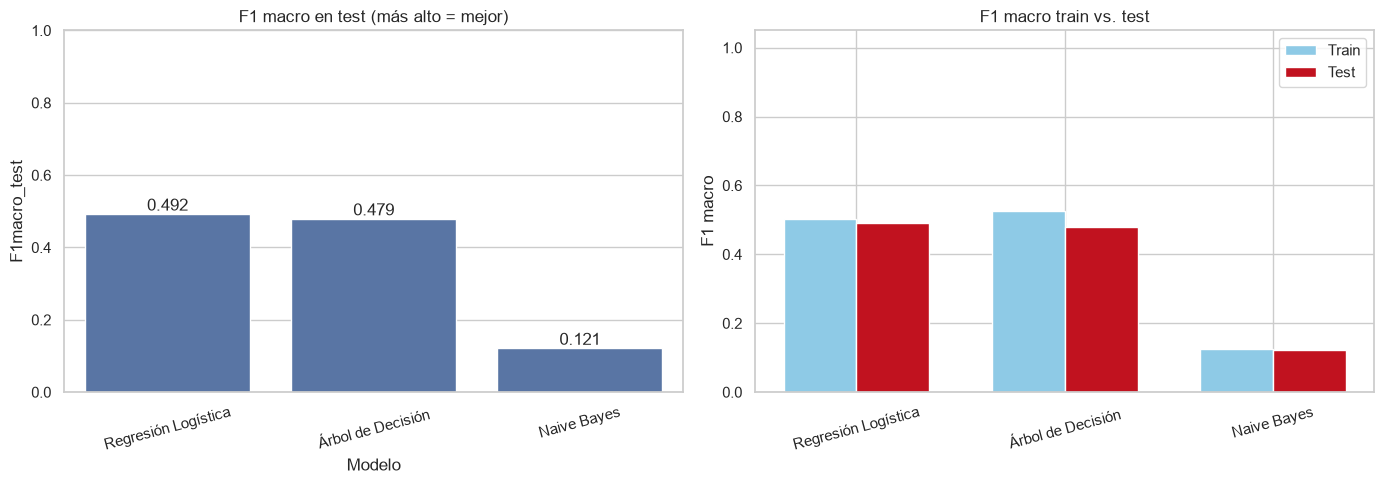

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_resultados, x="Modelo", y="F1macro_test", ax=axes[0], color="#4C72B0")
axes[0].set_title("F1 macro en test (más alto = mejor)")
axes[0].set_ylim(0, 1)
for i, v in enumerate(df_resultados["F1macro_test"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")

# F1 macro train vs test (diagnóstico de overfitting)
x = np.arange(len(df_resultados)); ancho = 0.35
axes[1].bar(x - ancho/2, df_resultados["F1macro_train"], ancho, label="Train", color="#8ecae6")
axes[1].bar(x + ancho/2, df_resultados["F1macro_test"], ancho, label="Test", color="#c1121f")
axes[1].set_xticks(x); axes[1].set_xticklabels(df_resultados["Modelo"], rotation=15)
axes[1].set_ylabel("F1 macro"); axes[1].set_title("F1 macro train vs. test")
axes[1].legend(); axes[1].set_ylim(0, 1.05)

for ax in axes[:1]:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### 9.2 Matrices de confusión (heatmap por modelo)
Normalizadas **por fila** (cada celda = proporción de la clase real): con un desbalance de este tamaño,
la matriz en conteos crudos sólo dejaría ver `W`. La diagonal es el recall por clase.
La confusión esperada es **RC ↔ SRC** (hormigón vs. acero-hormigón, estructuras similares).

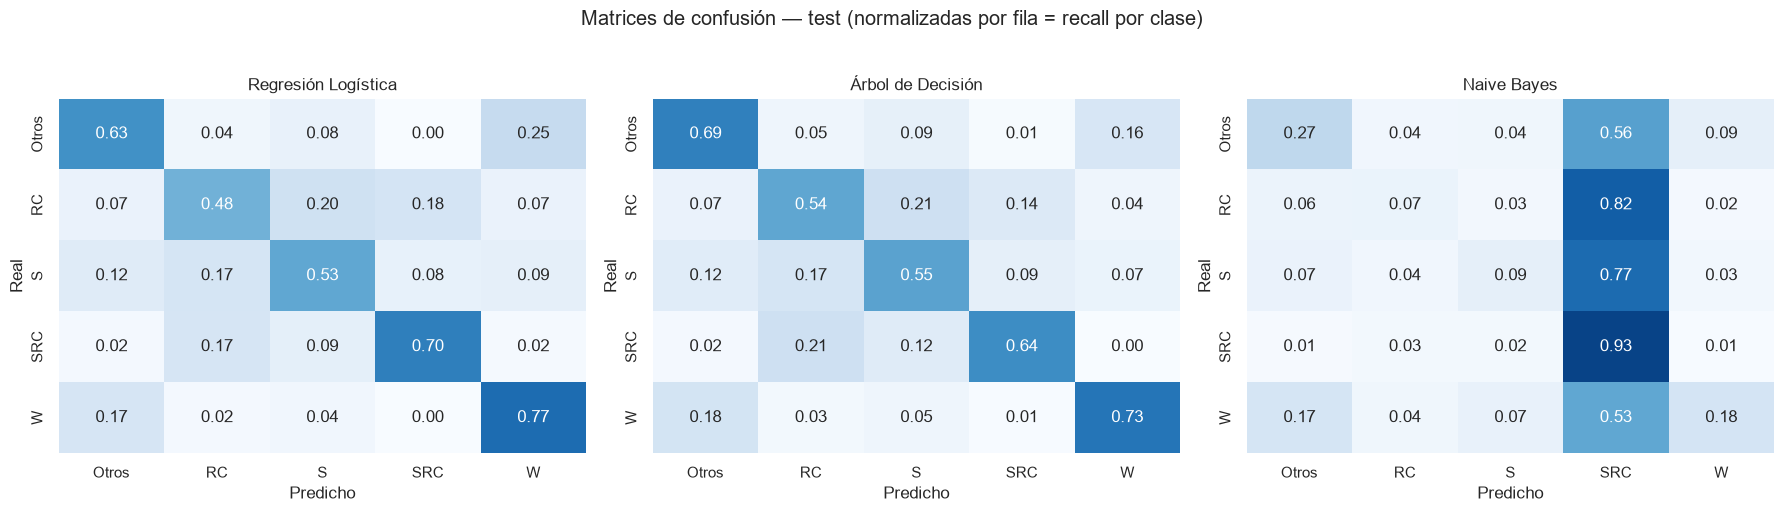

In [22]:
fig, axes = plt.subplots(1, len(modelos), figsize=(6 * len(modelos), 5))
if len(modelos) == 1:
    axes = [axes]

for ax, (nombre, pred) in zip(axes, predicciones_test.items()):
    # Normalizamos por fila (recall por clase): con el desbalance, los conteos crudos sólo muestran W.
    cm = confusion_matrix(y_test, pred, labels=clases, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, vmin=0, vmax=1,
                xticklabels=clases, yticklabels=clases, cbar=False)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(f"{nombre}")

plt.suptitle("Matrices de confusión — test (normalizadas por fila = recall por clase)", y=1.02)
plt.tight_layout()
plt.show()

### 9.3 Reporte por clase del mejor modelo
Precision / recall / F1 por clase (`classification_report`), para ver en qué clase concreta falla cada
modelo — sobre todo en la minoritaria.

In [23]:
mejor_nombre = df_resultados.sort_values("F1macro_test", ascending=False).iloc[0]["Modelo"]
print("Mejor modelo por F1 macro en test:", mejor_nombre, "\n")
print(classification_report(y_test, predicciones_test[mejor_nombre], digits=3, zero_division=0))

Mejor modelo por F1 macro en test: Regresión Logística 

              precision    recall  f1-score   support

       Otros      0.110     0.629     0.188      1360
          RC      0.518     0.485     0.501      3347
           S      0.450     0.533     0.488      3369
         SRC      0.306     0.698     0.426       553
           W      0.969     0.769     0.858     36296

    accuracy                          0.725     44925
   macro avg      0.471     0.623     0.492     44925
weighted avg      0.863     0.725     0.778     44925



## 10. ROC-AUC (one-vs-rest)
En multiclase reportamos el AUC promedio one-vs-rest (macro), que resume la capacidad de separar cada
clase del resto usando las probabilidades predichas.

In [24]:
y_test_bin = label_binarize(y_test, classes=clases)

print("ROC-AUC one-vs-rest (macro):")
for nombre, proba in proba_test.items():
    try:
        auc = roc_auc_score(y_test_bin, proba, average="macro", multi_class="ovr")
        print(f"  {nombre:22s}: {auc:.3f}")
    except ValueError as e:
        print(f"  {nombre:22s}: no calculable ({e})")

ROC-AUC one-vs-rest (macro):
  Regresión Logística   : 0.903
  Árbol de Decisión     : 0.891
  Naive Bayes           : 0.579


## 11. Extensiones valoradas

### 11.1 Importancia de variables (mejor modelo basado en árbol)
Si el mejor es Random Forest o XGBoost, extraemos `feature_importances_`, reconstruyendo los nombres tras
el One-Hot.

In [25]:
def nombres_features(pipe):
    prep = pipe.named_steps["prep"]
    nombres = list(cols_numericas)
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    nombres += list(ohe.get_feature_names_out(cols_categoricas))
    return nombres

modelo_final = pipelines_entrenados[mejor_nombre].named_steps["model"]
if hasattr(modelo_final, "feature_importances_"):
    nombres = nombres_features(pipelines_entrenados[mejor_nombre])
    imp = pd.Series(modelo_final.feature_importances_, index=nombres).sort_values(ascending=False)
    top = imp.head(15)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=top.values, y=top.index, color="#4C72B0")
    plt.title(f"Top 15 variables — {mejor_nombre}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    display(top.to_frame("importancia"))
else:
    print("El mejor modelo es lineal; se omiten feature_importances_.")

El mejor modelo es lineal; se omiten feature_importances_.


### 11.2 Ajuste de hiperparámetros (GridSearchCV sobre Random Forest)
Búsqueda acotada optimizando **F1 macro** en CV 3-fold estratificada.

In [26]:
from sklearn.model_selection import RandomizedSearchCV

# NOTA DE COSTO: un GridSearchCV completo sobre este volumen es inviable en escritorio.
# Usamos RandomizedSearchCV con pocas combinaciones y profundidades ya acotadas.
pipe_rf = Pipeline([("prep", preprocesador),
                    ("model", RandomForestClassifier(class_weight="balanced",
                                                     random_state=RANDOM_STATE, n_jobs=-1))])

espacio = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [12, 20, 30],
    "model__min_samples_leaf": [5, 10, 20],
}

grid = RandomizedSearchCV(pipe_rf, espacio, n_iter=5,
                          cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                          scoring="f1_macro", n_jobs=1, random_state=RANDOM_STATE)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor F1 macro en CV: {grid.best_score_:.3f}")
pred_grid = grid.predict(X_test)
print(f"F1 macro test (RF tuneado): {f1_score(y_test, pred_grid, average='macro'):.3f}")

Mejores hiperparámetros: {'model__n_estimators': 100, 'model__min_samples_leaf': 10, 'model__max_depth': 20}
Mejor F1 macro en CV: 0.534
F1 macro test (RF tuneado): 0.540


### 11.3 Clustering (K-Means + PCA) vs. clases reales
Pregunta del PDF: ¿la ubicación + tamaño + antigüedad agrupa los inmuebles **igual que su estructura**?
Corremos K-Means con `k = nº de clases` sobre las features preprocesadas (incluye `ward`), reducimos con
PCA a 2D para visualizar, y medimos la coincidencia clusters↔clases con el **Adjusted Rand Index**.

Adjusted Rand Index (clusters vs. estructura real): 0.211


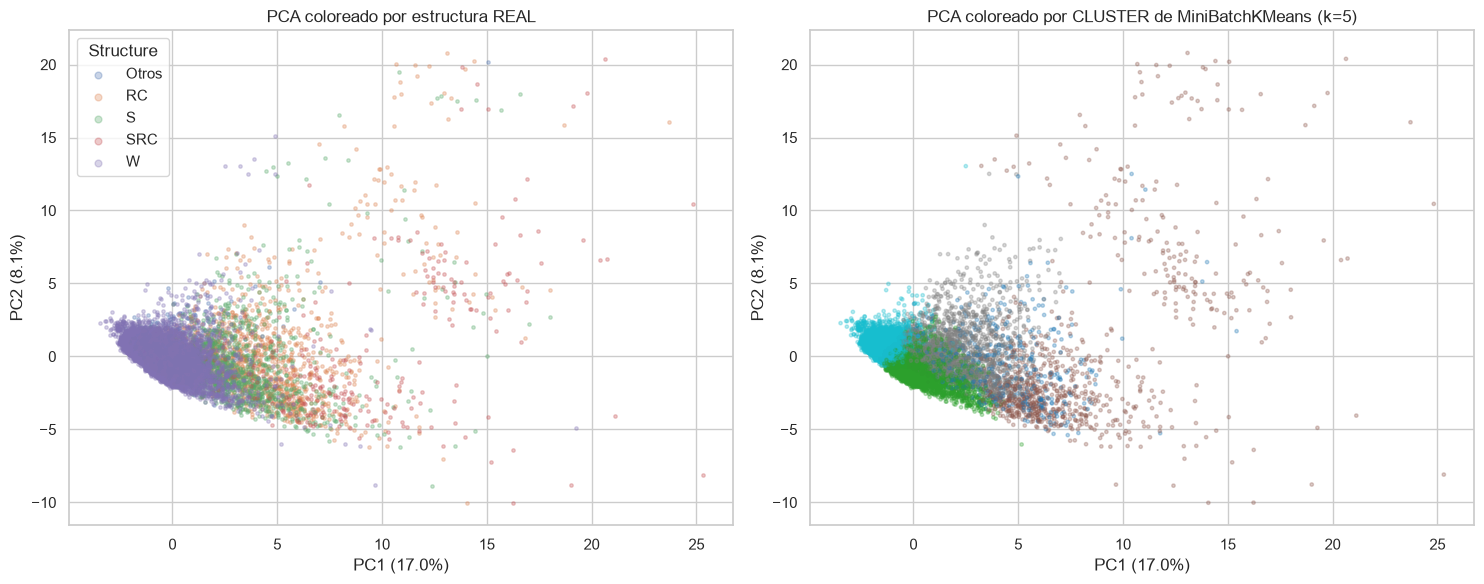

In [27]:
# Matriz de features preprocesada (misma que ven los modelos), sobre TODO el subconjunto con edificio.
X_prep = preprocesador.fit_transform(X)
X_prep = X_prep.toarray() if hasattr(X_prep, "toarray") else np.asarray(X_prep)

k = len(clases)
# MiniBatchKMeans en lugar de KMeans: con 200k+ filas es órdenes de magnitud más rápido
# y converge a una solución prácticamente equivalente.
kmeans = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, batch_size=4096)
clusters = kmeans.fit_predict(X_prep)

# Coincidencia clusters vs. clases reales (ARI: 1 = idénticos, 0 = azar).
ari = adjusted_rand_score(y, clusters)
print(f"Adjusted Rand Index (clusters vs. estructura real): {ari:.3f}")

# Visualización 2D con PCA. Submuestreamos para que el scatter sea legible y rápido.
idx_vis = np.random.RandomState(RANDOM_STATE).choice(
    len(X_prep), size=min(20000, len(X_prep)), replace=False)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_prep[idx_vis])
var = pca.explained_variance_ratio_
y_vis, clusters_vis = np.asarray(y)[idx_vis], clusters[idx_vis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for cl in clases:
    m = (y_vis == cl)
    axes[0].scatter(X_2d[m, 0], X_2d[m, 1], s=6, alpha=0.3, label=cl)
axes[0].set_title("PCA coloreado por estructura REAL")
axes[0].legend(title="Structure", markerscale=2)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_vis, s=6, alpha=0.3, cmap="tab10")
axes[1].set_title(f"PCA coloreado por CLUSTER de MiniBatchKMeans (k={k})")

for ax in axes:
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

### 11.4 Métodos de ensamble (sección D.2 del enunciado)

Se implementan **dos ensambles de tipos distintos**, entrenados con la misma función y las mismas
métricas que los clasificadores de la sección B:

- **Random Forest** (*bagging*): entrena múltiples árboles sobre remuestreos del conjunto y promedia
  sus predicciones. Al compartir modelo base con el Árbol de Decisión de la sección B, la diferencia
  entre ambos **aísla el efecto del bagging**.
- **XGBoost** (*boosting*): construye árboles de forma secuencial, donde cada uno corrige los errores
  del anterior. Contrasta la estrategia secuencial contra la paralela del *bagging*.

La pregunta que plantea el enunciado —*¿la ganancia justifica el aumento de complejidad?*— se responde
al final de esta sección, contrastando la mejora en F1 macro contra el costo en interpretabilidad y
tiempo de entrenamiento.

In [28]:
# ---------------------------------------------------------------------------------------------
# SECCIÓN D.2 — Definición y entrenamiento de los métodos de ensamble.
# ---------------------------------------------------------------------------------------------
if HAY_XGB:
    # tree_method="hist" y GPU aceleran mucho con 200k+ filas. XGBoost no admite class_weight en
    # multiclase: el desbalance se gestiona vía métricas macro y el análisis por clase.
    modelo_boosting = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", eval_metric="mlogloss",
        tree_method="hist", device="cuda" if USAR_GPU else "cpu",
        random_state=RANDOM_STATE, n_jobs=-1)
    nombre_boosting = "XGBoost"
else:
    modelo_boosting = GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    nombre_boosting = "GradientBoosting"

ensambles = {
    # Bagging: mismo modelo base que el Árbol de la sección B -> la diferencia mide el bagging.
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=5, max_features="sqrt",
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    nombre_boosting: modelo_boosting,
}

print("=== SECCIÓN D.2 — Métodos de ensamble ===")
for nombre, modelo in ensambles.items():
    entrenar_y_evaluar(nombre, modelo, "D.2 - Ensamble")

# La tabla se reconstruye incorporando los ensambles al registro compartido.
df_resultados = pd.DataFrame(resultados)
modelos_todos = {**modelos, **ensambles}

=== SECCIÓN D.2 — Métodos de ensamble ===
Random Forest           CV F1macro=0.551±0.002  F1macro(test)=0.554  Acc(test)=0.772  brecha train-test=+0.096
XGBoost                 CV F1macro=0.570±0.004  F1macro(test)=0.568  Acc(test)=0.892  brecha train-test=+0.057


In [29]:
# ---------------------------------------------------------------------------------------------
# ¿La ganancia del ensamble justifica el aumento de complejidad?
# ---------------------------------------------------------------------------------------------
comparacion = df_resultados.set_index("Modelo")[
    ["Bloque", "F1macro_test", "Kappa_test", "Acc_test"]].copy()

base_lineal = comparacion.loc["Regresión Logística", "F1macro_test"]
comparacion["Δ vs. baseline"] = (comparacion["F1macro_test"] - base_lineal).round(3)

if "Árbol de Decisión" in comparacion.index:
    base_arbol = comparacion.loc["Árbol de Decisión", "F1macro_test"]
    comparacion["Δ vs. árbol"] = (comparacion["F1macro_test"] - base_arbol).round(3)

# El costo no es sólo computacional: la interpretabilidad es un requisito real en dominios
# donde una predicción debe poder justificarse ante un tercero.
costo = {
    "Regresión Logística": "Coeficientes interpretables; entrenamiento rápido.",
    "Árbol de Decisión":   "Reglas visualizables; entrenamiento rápido.",
    "Naive Bayes":         "Probabilidades por clase; entrenamiento casi instantáneo.",
    "Random Forest":       "200 árboles: no inspeccionable; entrenamiento costoso.",
    "XGBoost":             "Caja negra sin SHAP; costoso, pero acelerable por GPU.",
    "GradientBoosting":    "Caja negra; secuencial, no paralelizable.",
}
comparacion["Costo / interpretabilidad"] = [costo.get(m, "") for m in comparacion.index]
display(comparacion.round(3))

if {"Árbol de Decisión", "Random Forest"} <= set(comparacion.index):
    ganancia_bagging = comparacion.loc["Random Forest", "F1macro_test"] - base_arbol
    print(f"\nEfecto aislado del BAGGING (Árbol -> Random Forest): {ganancia_bagging:+.3f} en F1 macro.")
    print("Ambos comparten el mismo modelo base, así que la diferencia mide el aporte del ensamble.")

mejor_individual = comparacion[comparacion["Bloque"] == "B - Individual"]["F1macro_test"].max()
mejor_ensamble = comparacion[comparacion["Bloque"] == "D.2 - Ensamble"]["F1macro_test"].max()
print(f"\nMejor individual (sección B): {mejor_individual:.3f}  |  "
      f"Mejor ensamble (sección D.2): {mejor_ensamble:.3f}  |  "
      f"Ganancia: {mejor_ensamble - mejor_individual:+.3f}")

,Bloque,F1macro_test,Kappa_test,Acc_test,Δ vs. baseline,Δ vs. árbol,Costo / interpretabilidad
Modelo,,,,,,,
Regresión Logística,B - Individual,0.492,0.408,0.725,0.000,0.013,Coeficientes interpretables; entrenamiento ráp...
Árbol de Decisión,B - Individual,0.479,0.395,0.703,-0.013,0.000,Reglas visualizables; entrenamiento rápido.
Naive Bayes,B - Individual,0.121,0.038,0.175,-0.371,-0.358,Probabilidades por clase; entrenamiento casi i...
Random Forest,D.2 - Ensamble,0.554,0.485,0.772,0.062,0.075,200 árboles: no inspeccionable; entrenamiento ...
XGBoost,D.2 - Ensamble,0.568,0.636,0.892,0.076,0.089,"Caja negra sin SHAP; costoso, pero acelerable ..."



Efecto aislado del BAGGING (Árbol -> Random Forest): +0.075 en F1 macro.
Ambos comparten el mismo modelo base, así que la diferencia mide el aporte del ensamble.

Mejor individual (sección B): 0.492  |  Mejor ensamble (sección D.2): 0.568  |  Ganancia: +0.076


## 12. Serialización del mejor clasificador (insumo para el TP4)
Guardamos el mejor modelo como `Pipeline` único (preproc + modelo) con `joblib`, junto con el mapeo de
clases. Candidato a desplegarse en la app del TP4.

In [30]:
import joblib

# Despliegue: el mejor de TODOS los modelos (secciones B y D.2), recomputado aquí una vez
# que la seccion 11.4 sumo los ensambles al registro. Asi el artefacto serializado coincide
# con el modelo desplegado en el TP4 (XGBoost), no con el mejor clasificador individual.
mejor_nombre = df_resultados.sort_values("F1macro_test", ascending=False).iloc[0]["Modelo"]

usa_int = mejor_nombre in ("XGBoost", "GradientBoosting")
y_full = np.array([clase_a_int[v] for v in y]) if usa_int else y

# Reentrenar el mejor pipeline sobre TODO el subconjunto con edificio, para el artefacto de despliegue.
pipe_deploy = Pipeline([("prep", preprocesador), ("model", modelos_todos[mejor_nombre])])
pipe_deploy.fit(X, y_full)

artefacto = {
    "pipeline": pipe_deploy,
    "target": TARGET,
    "clases": clases,
    "clase_a_int": clase_a_int,
    "int_a_clase": int_a_clase,
    "usa_int": usa_int,
    "cols_numericas": cols_numericas,
    "cols_categoricas": cols_categoricas,
    "modelo": mejor_nombre,
}
ruta = f"{MODEL_DIR}/tp3_mejor_clasificador.joblib"
joblib.dump(artefacto, ruta)
print("Modelo serializado en:", ruta)

# Prueba rápida de carga y predicción.
cargado = joblib.load(ruta)
ejemplo = X.iloc[[0]]
pred_raw = cargado["pipeline"].predict(ejemplo)[0]
pred_clase = cargado["int_a_clase"][pred_raw] if cargado["usa_int"] else pred_raw
print(f"Predicción de ejemplo (fila 0): {pred_clase}  |  real: {y[0]}")

Modelo serializado en: outputs/models/tp3_mejor_clasificador.joblib
Predicción de ejemplo (fila 0): W  |  real: W
